# Exploratory Data Analysis: Fraud Detection

This notebook explores the raw banking transaction data before it enters the ML pipeline. The goal is to understand the data structure, identify the strongest fraud signals, and motivate the 60+ features engineered in the [transformation layer](../docs/2-transformation.md).

**What we'll find:**
- Fraud rate is ~0.15% (1 in 665 transactions), making class imbalance the central challenge
- Error flags (Bad CVV, Bad Expiration) are the strongest individual signals, with fraud rates 10-23x the baseline
- Online transactions have 28x the fraud rate compared to swipe
- Temporal patterns exist (fraud peaks at night) but are weaker than error/channel signals

These insights directly informed the feature engineering and model design described in the [fraud detection guide](../docs/3-ml-fraud-detection.md).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

FRAUD_COLOR = "#e74c3c"
LEGIT_COLOR = "#3498db"

## Load Data

We load the raw transactions CSV, merge fraud labels, and parse the key fields. The dataset has ~13M transactions spanning 2010 to 2019.

In [2]:
# Load transactions
df = pd.read_csv("../data/raw/transactions_data.csv", parse_dates=["date"])
df["amount_num"] = df["amount"].str.replace("$", "", regex=False).astype(float)

# Load and merge fraud labels
with open("../data/raw/train_fraud_labels.json") as f:
    labels = json.load(f)["target"]
label_map = {int(k): 1 if v == "Yes" else 0 for k, v in labels.items()}
df["is_fraud"] = df["id"].map(label_map)

# Parse error flags
df["has_error"] = df["errors"].notna() & (df["errors"].str.strip() != "")

print(f"Transactions: {len(df):,}")
print(f"Date range:   {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Labeled:      {df['is_fraud'].notna().sum():,} ({df['is_fraud'].notna().mean():.0%})")
print(f"Fraud rate:   {df['is_fraud'].mean():.4%} (1 in {1/df['is_fraud'].mean():.0f})")

Transactions: 13,305,915
Date range:   2010-01-01 to 2019-10-31
Labeled:      8,914,963 (67%)
Fraud rate:   0.1495% (1 in 669)


## Class Imbalance

The fraud rate is ~0.15%. A model that predicts "no fraud" for every transaction achieves 99.85% accuracy but catches zero fraud. This is why we use AUPRC (Area Under Precision-Recall Curve) as the primary metric, not accuracy.

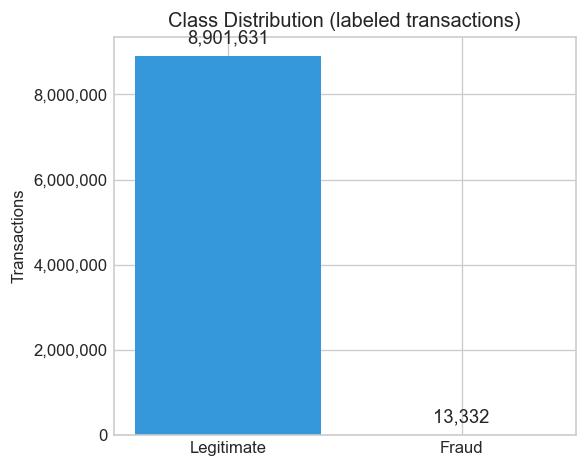

In [3]:
# Only use labeled rows for fraud analysis
labeled = df[df["is_fraud"].notna()].copy()

fig, ax = plt.subplots(figsize=(5, 4))
counts = labeled["is_fraud"].value_counts().sort_index()
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=[LEGIT_COLOR, FRAUD_COLOR])
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in counts.values], padding=5, fontsize=11)
ax.set_ylabel("Transactions")
ax.set_title("Class Distribution (labeled transactions)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## Fraud Rate by Error Type

Error flags turned out to be the single most impactful feature category. The raw `errors` column contains values like "Bad CVV", "Bad Expiration", etc. Parsing these into boolean flags and computing fraud rates reveals massive signal.

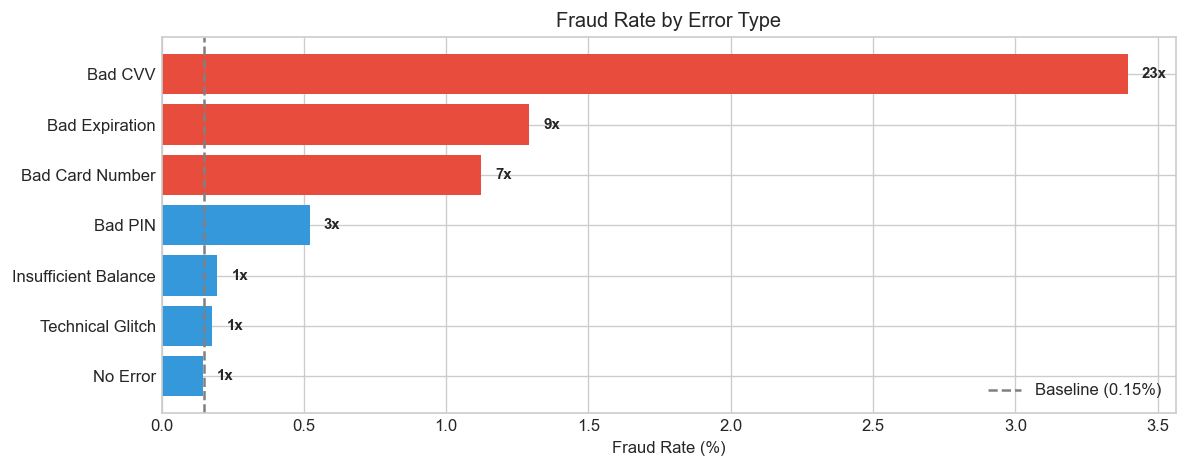

In [4]:
error_types = ["Bad CVV", "Bad Expiration", "Bad Card Number", "Bad PIN",
               "Insufficient Balance", "Technical Glitch"]
base_rate = labeled["is_fraud"].mean()

rows = []
for err in error_types:
    mask = labeled["errors"].str.contains(err, case=False, na=False)
    rate = labeled.loc[mask, "is_fraud"].mean()
    rows.append({"Error Type": err, "Fraud Rate": rate, "Multiplier": rate / base_rate, "Count": mask.sum()})

rows.append({"Error Type": "No Error", "Fraud Rate": labeled.loc[~labeled["has_error"], "is_fraud"].mean(),
             "Multiplier": labeled.loc[~labeled["has_error"], "is_fraud"].mean() / base_rate,
             "Count": (~labeled["has_error"]).sum()})

err_df = pd.DataFrame(rows).sort_values("Fraud Rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [FRAUD_COLOR if r > base_rate * 5 else LEGIT_COLOR for r in err_df["Fraud Rate"]]
bars = ax.barh(err_df["Error Type"], err_df["Fraud Rate"] * 100, color=colors)
ax.axvline(base_rate * 100, color="gray", linestyle="--", label=f"Baseline ({base_rate:.2%})")
ax.set_xlabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Error Type")
for bar, mult in zip(bars, err_df["Multiplier"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{mult:.0f}x", va="center", fontsize=9, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Fraud Rate by Payment Channel

The `use_chip` field distinguishes between Chip, Swipe, and Online transactions. Online transactions have a dramatically higher fraud rate.

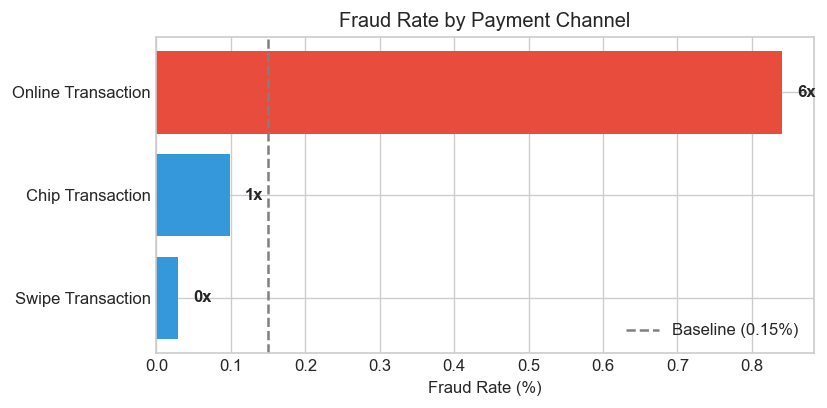

In [5]:
channel = labeled.groupby("use_chip")["is_fraud"].agg(["mean", "count"]).sort_values("mean")
channel["multiplier"] = channel["mean"] / base_rate

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [FRAUD_COLOR if m > 5 else LEGIT_COLOR for m in channel["multiplier"]]
bars = ax.barh(channel.index, channel["mean"] * 100, color=colors)
ax.axvline(base_rate * 100, color="gray", linestyle="--", label=f"Baseline ({base_rate:.2%})")
ax.set_xlabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Payment Channel")
for bar, mult in zip(bars, channel["multiplier"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{mult:.0f}x", va="center", fontsize=10, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Temporal Patterns

Fraud doesn't happen uniformly throughout the day. We'd expect higher rates during off-hours when cardholders are less likely to notice suspicious activity.

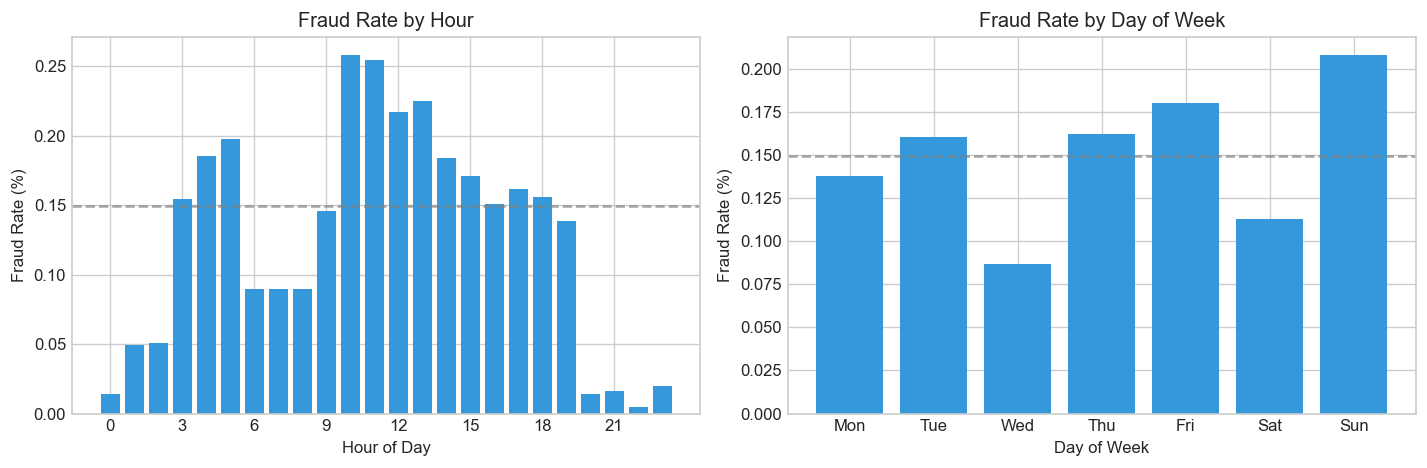

In [6]:
labeled["txn_hour"] = labeled["date"].dt.hour
labeled["txn_dow"] = labeled["date"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By hour
hourly = labeled.groupby("txn_hour")["is_fraud"].mean() * 100
axes[0].bar(hourly.index, hourly.values, color=LEGIT_COLOR)
axes[0].axhline(base_rate * 100, color="gray", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_title("Fraud Rate by Hour")
axes[0].set_xticks(range(0, 24, 3))

# By day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = labeled.groupby("txn_dow")["is_fraud"].mean().reindex(dow_order) * 100
axes[1].bar(range(7), daily.values, color=LEGIT_COLOR)
axes[1].axhline(base_rate * 100, color="gray", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order])

plt.tight_layout()
plt.show()

## Amount Distribution

Do fraudulent transactions look different in terms of amount? Comparing the distribution of absolute transaction amounts between fraud and legitimate transactions.

/var/folders/c6/p9vlt5_n15947lfjts27mm2r0000gp/T/ipykernel_61047/3654300244.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([legit_amounts, fraud_amounts], labels=["Legitimate", "Fraud"],


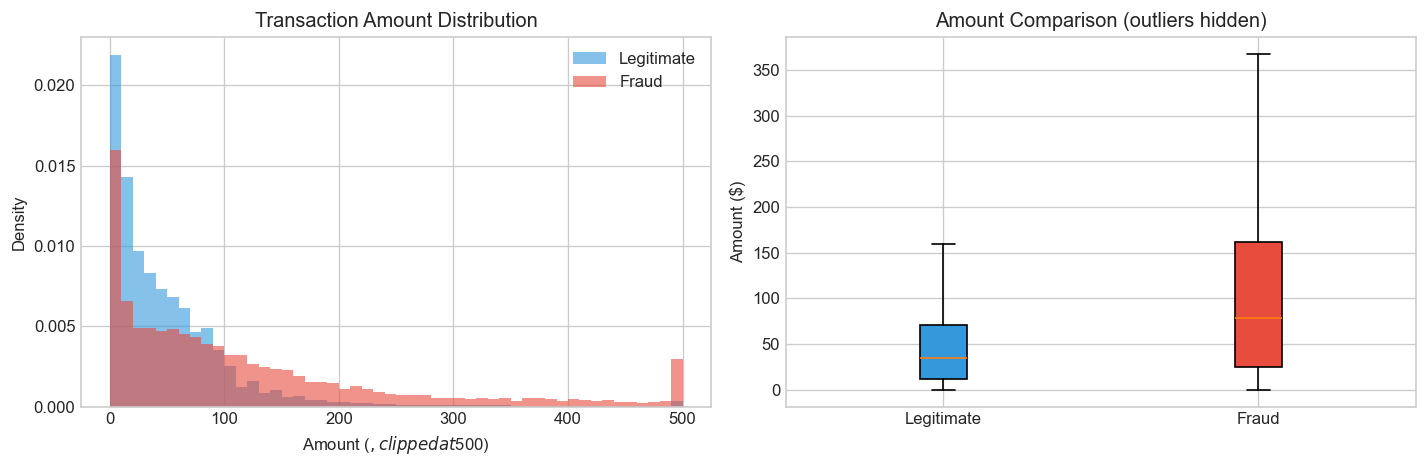

Median amount - Legit: $34.77, Fraud: $78.14


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Log-scale histogram
for label, color, name in [(0, LEGIT_COLOR, "Legitimate"), (1, FRAUD_COLOR, "Fraud")]:
    subset = labeled[labeled["is_fraud"] == label]["amount_num"].abs()
    axes[0].hist(subset.clip(upper=500), bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel("Amount ($, clipped at $500)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction Amount Distribution")
axes[0].legend()

# Boxplot comparison (log scale)
fraud_amounts = labeled[labeled["is_fraud"] == 1]["amount_num"].abs()
legit_amounts = labeled[labeled["is_fraud"] == 0]["amount_num"].abs()
bp = axes[1].boxplot([legit_amounts, fraud_amounts], labels=["Legitimate", "Fraud"],
                     patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor(LEGIT_COLOR)
bp["boxes"][1].set_facecolor(FRAUD_COLOR)
axes[1].set_ylabel("Amount ($)")
axes[1].set_title("Amount Comparison (outliers hidden)")

plt.tight_layout()
plt.show()

print(f"Median amount - Legit: ${legit_amounts.median():.2f}, Fraud: ${fraud_amounts.median():.2f}")

## Geographic Signal

We approximate each client's "home state" as their most frequent `merchant_state`, then check whether out-of-state transactions have a higher fraud rate.

In [8]:
# Compute each client's home state (most frequent merchant_state)
home_state = (labeled[labeled["merchant_state"].notna() & (labeled["merchant_state"] != "")]
              .groupby("client_id")["merchant_state"]
              .agg(lambda x: x.value_counts().index[0])
              .rename("home_state"))

geo = labeled.merge(home_state, on="client_id", how="left")
geo["out_of_state"] = (geo["merchant_state"] != geo["home_state"]) & geo["home_state"].notna()

geo_rates = geo.groupby("out_of_state")["is_fraud"].mean()
print("Fraud rate by location:")
print(f"  In-state:     {geo_rates[False]:.4%}")
print(f"  Out-of-state: {geo_rates[True]:.4%}")
print(f"  Multiplier:   {geo_rates[True] / geo_rates[False]:.1f}x")

Fraud rate by location:
  In-state:     0.0129%
  Out-of-state: 0.6788%
  Multiplier:   52.7x


## Features Engineered

Based on this EDA, the [dbt transformation layer](../docs/2-transformation.md) computes 60+ features in `mart_fraud_features`. These are grouped into 8 categories:

| Category | Count | Examples | Signal Source |
|----------|-------|---------|---------------|
| **Amount** | 10 | `abs_amount`, `amount_zscore`, `amount_to_limit_ratio` | Unusual spend relative to client history |
| **Time** | 5 | `txn_hour`, `is_weekend`, `is_night_txn` | Off-hours activity |
| **Errors** | 7 | `has_bad_cvv`, `has_any_error`, `card_errors_7d` | Failed authentication attempts (23x signal) |
| **Velocity** | 5 | `card_txn_count_1h`, `seconds_since_last_txn` | Rapid card testing patterns |
| **Behavioral** | 7 | `is_new_merchant`, `card_mcc_freq`, `rapid_succession` | Deviation from cardholder habits |
| **Geographic** | 2 | `is_online`, `is_out_of_home_state` | Channel and location anomalies (28x signal) |
| **Card/User** | 8 | `card_age_months`, `credit_score`, `debt_to_income_ratio` | Risk profile |
| **Combined** | 4 | `online_new_merchant`, `error_online` | Compound risk signals |

All features are computed in SQL via window functions on BigQuery. The full SQL and design decisions are documented in the [transformation guide](../docs/2-transformation.md).

## Key Takeaways

1. **Error flags are the strongest signals.** Bad CVV alone has a 23x fraud rate multiplier. These features didn't exist in the raw data and had to be parsed from a free-text string.

2. **Online channel dominates.** 28x the fraud rate compared to swipe transactions. The `is_online` flag is a simple but powerful feature.

3. **Temporal patterns are real but weaker.** Fraud peaks during night hours, but the signal is less dramatic than errors or channel.

4. **Class imbalance is extreme.** At 0.15%, standard accuracy metrics are useless. This drives the choice of focal loss over class weights in the model (see [fraud detection guide](../docs/3-ml-fraud-detection.md)).

5. **Amount alone is not enough.** Fraud amounts don't differ dramatically from legitimate ones. The model needs contextual features (amount relative to client history, credit limit ratio) to detect anomalies.

**Next:** See how these features are used in the [fraud detection model](../docs/3-ml-fraud-detection.md) and [expense forecasting model](../docs/ml-expense-forecast.md).